# Jupiter(-like planets) Cloud Model using Ackerman and Marley Cloud Model.

Here, we try to compute a cloud opacity using Ackerman and Marley Model.
We consider ammonia and water clouds.  


In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

Setting a simple atmopheric model. We need the density of atmosphere.

In [2]:
from exojax.utils.constants import bar_cgs, kB, m_u
from exojax.atm.atmprof import pressure_layer_logspace

Parr, dParr, k = pressure_layer_logspace(log_pressure_top=-5., log_pressure_btm=4.0, nlayer=100)
alpha = 0.097
T0 = 200.
Tarr = T0 * (Parr)**alpha

mu = 2.0  # mean molecular weight
R = kB / (mu * m_u)
rho = Parr * bar_cgs / (R * Tarr)  # pressure: bar to dyn/cm2


The solar abundance can be obtained using utils.zsol.nsol. Here, we assume a maximum VMR for NH3 and H2O from solar abundance. 

In [3]:
from exojax.utils.zsol import nsol

n = nsol()  #solar abundance
VMR_h2o = n["O"]
VMR_nh3 = n["N"]


Database for solar abundance =  AAG21
Asplund, M., Amarsi, A. M., & Grevesse, N. 2021, arXiv:2105.01661


Vapor saturation pressures can be obtained using atm.psat

In [4]:
from exojax.atm.psat import psat_ammonia_AM01, psat_water_AM01
psat_nh3 = psat_ammonia_AM01(Tarr)
psat_h2o = psat_water_AM01(Tarr)


Compute a cloud base pressure.

In [5]:
from exojax.atm.amclouds import compute_cloud_base_pressure

pbase_nh3 = compute_cloud_base_pressure(Parr, psat_nh3, VMR_nh3)
pbase_h2o = compute_cloud_base_pressure(Parr, psat_h2o, VMR_h2o)


The cloud base is located at the intersection of a TP profile and the vapor saturation puressure devided by VMR.

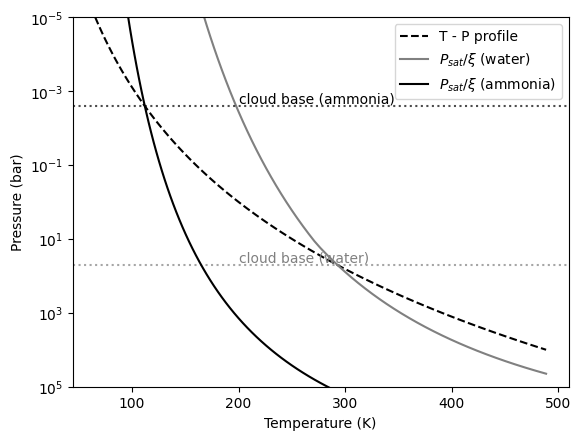

In [6]:
plt.plot(Tarr, Parr, color="black", ls="dashed", label="T - P profile")

plt.plot(Tarr, psat_h2o / VMR_h2o, label="$P_{sat}/\\xi$ (water)", color="gray")
plt.axhline(pbase_h2o, color="gray", alpha=0.7, ls="dotted")
plt.text(200, pbase_h2o * 0.8, "cloud base (water)", color="gray")

plt.plot(Tarr, psat_nh3 / VMR_nh3, label="$P_{sat}/\\xi$ (ammonia)", color="black")
plt.axhline(pbase_nh3, color="black", alpha=0.7, ls="dotted")
plt.text(200,  pbase_nh3 * 0.8, "cloud base (ammonia)", color="black")


plt.yscale("log")
plt.ylim(1.0e-5, 1.0e5)
#plt.xlim(0, 3000)
plt.gca().invert_yaxis()
plt.legend()
plt.xlabel("Temperature (K)")
plt.ylabel("Pressure (bar)")
plt.savefig("pbase.pdf", bbox_inches="tight", pad_inches=0.0)
plt.savefig("pbase.png", bbox_inches="tight", pad_inches=0.0)
plt.show()

Compute VMRs of clouds. Because Parr is an array, we apply jax.vmap to atm.amclouds.mixing_ratio_cloud_profile.

In [7]:
from exojax.atm.amclouds import mixing_ratio_cloud_profile

fsed = 3
VMRbase_nh3 = VMR_nh3
VMRc_nh3 = mixing_ratio_cloud_profile(Parr, pbase_nh3, fsed, VMR_nh3)


VMRbase_h2o = VMR_h2o
VMRc_h2o = mixing_ratio_cloud_profile(Parr, pbase_h2o, fsed, VMR_h2o)




Here is the VMR distribution.

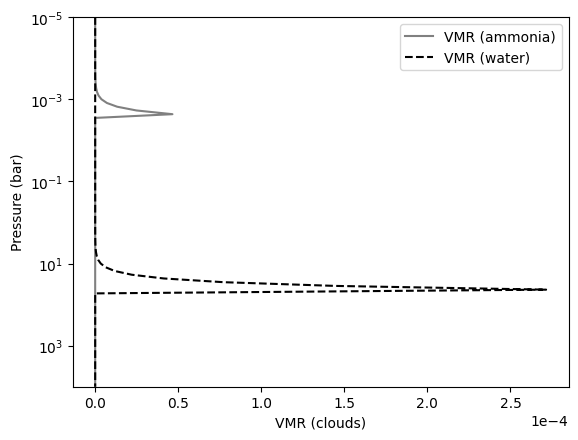

In [8]:
plt.figure()
plt.gca().get_xaxis().get_major_formatter().set_powerlimits([-3, 3])
plt.plot(VMRc_nh3, Parr, color="gray", label="VMR (ammonia)")
plt.plot(VMRc_h2o, Parr, color="black", ls="dashed", label="VMR (water)")

plt.yscale("log")
plt.ylim(1.e-5, 10000)
plt.gca().invert_yaxis()
plt.legend()
plt.xlabel("VMR (clouds)")
plt.ylabel("Pressure (bar)")
plt.savefig("vmrcloud.pdf", bbox_inches="tight", pad_inches=0.0)
plt.savefig("vmrcloud.png", bbox_inches="tight", pad_inches=0.0)
plt.show()

Compute dynamic viscosity in H2 atmosphere (cm/g/s)

In [9]:
from exojax.atm.viscosity import eta_Rosner, calc_vfactor

T = np.logspace(np.log10(1000), np.log10(2000))
vfactor, Tr = calc_vfactor("H2")
eta = eta_Rosner(T, vfactor)


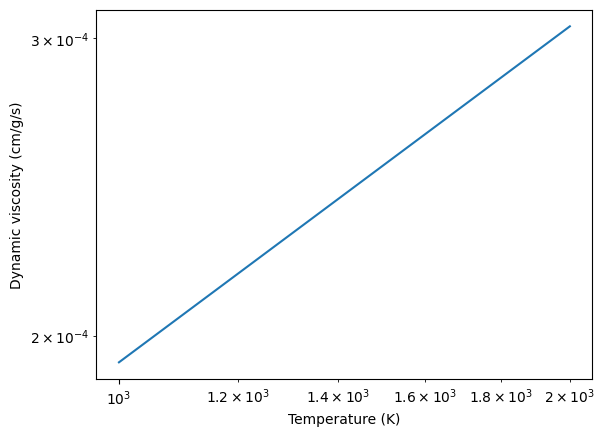

In [10]:
plt.plot(T, eta)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Temperature (K)")
plt.ylabel("Dynamic viscosity (cm/g/s)")
plt.show()

The pressure scale height can be computed using atm.atmprof.pressure_scale_height.

In [11]:
from exojax.atm.atmprof import pressure_scale_height

T = 1000  #K
mu = 2  #mean molecular weight
print("scale height=", pressure_scale_height(1.e5, T, mu), "cm")


scale height= 415722.98593912687 cm


We need a density of condensates. 

In [12]:

# for ammonia density
from exojax.atm.condensate import condensate_substance_density
Ttyp_ammonia = 100.0

#NH3 ice and H2O ice
rhoc_nh3 = condensate_substance_density["NH3"]
rhoc_h2o = condensate_substance_density["H2O"]

# NH3 water and H2O water
# we use water density from chempy (kg/m3), of course it's almost 1 g/cm3 though
#from chempy.properties.water_density_tanaka_2001 import water_density
#from exojax.utils.constants import Tc_water
#rhoc_h2o = water_density(Tc_water)*1.e-3
#from exojax.atm.condensate import condensate_density_liquid_ammonia
#rhoc_nh3 = condensate_density_liquid_ammonia(200.0)

print(rhoc_nh3, "g/cm3 (NH3)")
print(rhoc_h2o,"g/cm3 (H2O)")

from exojax.database.molinfo import molmass_isotope

mu = molmass_isotope("H2")
muc_nh3 = molmass_isotope("NH3")
muc_h2o = molmass_isotope("H2O")


0.84 g/cm3 (NH3)
0.93 g/cm3 (H2O)


Let's compute the terminal velocity. 
We can compute the terminal velocity of cloud particle using atm.vterm.terminal_velocity.
vmap is applied across atmospheric layers.

In [13]:
from exojax.atm.viscosity import calc_vfactor, eta_Rosner
from exojax.atm.vterm import terminal_velocity
from jax import vmap

vfactor, trange = calc_vfactor(atm="H2")
rarr = jnp.logspace(-5, -3, 2000)  #cm
drho_nh3 = rhoc_nh3 - rho
drho_h2o = rhoc_h2o - rho

eta_fid = eta_Rosner(Tarr, vfactor)

g = 1.e5
vf_vmap = vmap(terminal_velocity, (None, None, 0, 0, 0))
vfs_nh3 = vf_vmap(rarr, g, eta_fid, drho_nh3, rho)
vfs_h2o = vf_vmap(rarr, g, eta_fid, drho_h2o, rho)



Kzz/L will be used to calibrate $r_w$. following Ackerman and Marley 2001  

In [14]:
Kzz = 1.e5  #cm2/s
sigmag = 2.0


Tbase_nh3 = T0 * (pbase_nh3)**alpha
Tbase_h2o = T0 * (pbase_h2o)**alpha

L_nh3 = pressure_scale_height(g, Tbase_nh3, mu)
L_h2o = pressure_scale_height(g, Tbase_h2o, mu)


In [15]:
Kzz/L_nh3, Kzz/L_h2o

(Array(2.16345447, dtype=float64), Array(0.82729087, dtype=float64))

Check the powerlaw index of the terminal velocity. If it's within the Stokes flow, alpha should be 2.

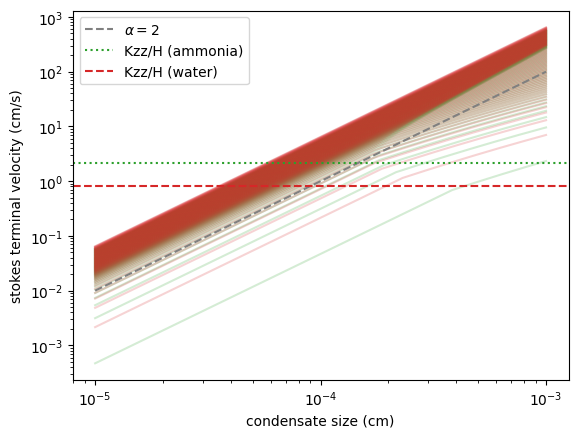

In [16]:
for i in range(0, len(Tarr)):
    plt.plot(rarr, vfs_nh3[i, :], alpha=0.2, color="C2")
    plt.plot(rarr, vfs_h2o[i, :], alpha=0.2, color="C3")
    
plt.plot(rarr, 1.e8*rarr**2,label="$\\alpha=2$",color="gray",ls="dashed")
plt.xscale("log")
plt.yscale("log")
plt.axhline(Kzz / L_nh3, label="Kzz/H (ammonia)", color="C2", ls="dotted")
plt.axhline(Kzz / L_h2o, label="Kzz/H (water)", color="C3", ls="dashed")
plt.ylabel("stokes terminal velocity (cm/s)")
plt.xlabel("condensate size (cm)")
plt.legend()

In [17]:
alphav = 2.0

Find the intersection.

In [18]:
from exojax.atm.amclouds import find_rw

vfind_rw = vmap(find_rw, (None, 0, None), 0)
rw_nh3 = vfind_rw(rarr, vfs_nh3, Kzz / L_nh3)
rw_h2o = vfind_rw(rarr, vfs_h2o, Kzz / L_h2o)



Then, $r_g$ can be computed from $r_w$ and other quantities.

In [19]:
from exojax.atm.amclouds import get_rg

rg_nh3 = get_rg(rw_nh3, fsed, alphav, sigmag)
rg_h2o = get_rg(rw_h2o, fsed, alphav, sigmag)



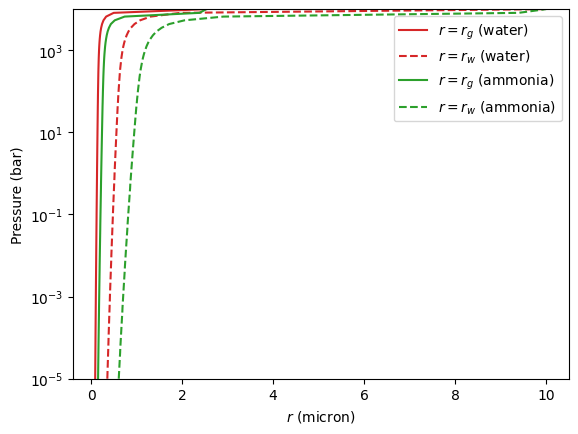

In [20]:
plt.plot(rg_h2o * 1.e4, Parr, label="$r=r_g$ (water)", color="C3")
plt.plot(rw_h2o * 1.e4, Parr, ls="dashed", label="$r=r_w$ (water)", color="C3")
plt.plot(rg_nh3 * 1.e4, Parr, label="$r=r_g$ (ammonia)", color="C2")
plt.plot(rw_nh3 * 1.e4, Parr, ls="dashed", label="$r=r_w$ (ammonia)", color="C2")

plt.ylim(1.e-5, 10000)
plt.xlabel("$r$ (micron)")
plt.ylabel("Pressure (bar)")
plt.yscale("log")
plt.savefig("rgrw.png")
plt.legend()

In [21]:
from exojax.database.pardb import PdbCloud
from exojax.database.mie import auto_rgrid, mie_lognormal
from tqdm import tqdm

# PdbCloud downloads the VIRGA refractive indices from Batalha and Marley (2020).
pdb_nh3 = PdbCloud("NH3")
wavenm = pdb_nh3.refraction_index_wavelength_nm[-30:-8][::-1]
m_nh3 = pdb_nh3.refraction_index[-30:-8][::-1]
npart = 1.e6  # particle number density (cm^-3)
rg_nm = float(rg_nh3[0]) * 1.e7  # radius: cm to nm
rgrid = auto_rgrid(rg_nm, sigmag)
mie = np.asarray([
    mie_lognormal(m, wav_nm, sigmag, rg_nm, npart, rgrid)
    for m, wav_nm in tqdm(zip(m_nh3, wavenm), total=len(wavenm))
])
print(mie)


.database/particulates/virga/virga.zip  exists. Remove it if you wanna re-download and unzip.
Refractive index file found:  .database/particulates/virga/NH3.refrind
Miegrid file does not exist at  .database/particulates/virga/miegrid_lognorm_NH3.mg.npz
Generate miegrid file using pdb.generate_miegrid if you use Mie scattering


  0%|          | 0/22 [00:00<?, ?it/s]

  5%|▍         | 1/22 [00:01<00:24,  1.17s/it]

 68%|██████▊   | 15/22 [00:01<00:00, 15.97it/s]

100%|██████████| 22/22 [00:01<00:00, 16.61it/s]

[[5.37431762e+05 5.37272605e+05 1.59156980e+02 7.23131450e-01
  1.48913044e+05 2.29177700e+05 9.23995822e+04]
 [5.36063725e+05 5.35904196e+05 1.59528577e+02 7.24727637e-01
  1.47679143e+05 2.17098214e+05 8.77183966e+04]
 [5.33921928e+05 5.33762994e+05 1.58934239e+02 7.26349323e-01
  1.46223539e+05 2.05638584e+05 8.32849989e+04]
 [5.30982645e+05 5.30819361e+05 1.63283978e+02 7.27950177e-01
  1.44572597e+05 1.95118987e+05 7.94913075e+04]
 [5.28025487e+05 5.27862375e+05 1.63112114e+02 7.29289219e-01
  1.43061148e+05 1.86663445e+05 7.65361072e+04]
 [5.25203041e+05 5.25039650e+05 1.63390537e+02 7.30435014e-01
  1.41695696e+05 1.78672472e+05 7.38147641e+04]
 [5.21986005e+05 5.21820410e+05 1.65595256e+02 7.31480770e-01
  1.40284410e+05 1.73089849e+05 7.20270190e+04]
 [5.18898567e+05 5.18731631e+05 1.66935921e+02 7.32433828e-01
  1.38961972e+05 1.67286221e+05 7.01303653e+04]
 [5.15588775e+05 5.15420520e+05 1.68254713e+02 7.33372000e-01
  1.37593797e+05 1.61707258e+05 6.84170611e+04]
 [5.120479

In [22]:
sigmag

2.0

The particle sizes here are mainly submicron. The following geometric-cross-section calculation is an illustrative approximation, not a quantitative treatment of these small particles. Use the Mie calculation above for wavelength-dependent optical properties. The final emission example also treats cloud extinction as absorption and does not include scattering.


In [23]:
from exojax.rt.layeropacity import layer_optical_depth_cloudgeo
from exojax.atm.atmconvert import vmr_to_mmr

dtau_nh3 = layer_optical_depth_cloudgeo(
    dParr, rhoc_nh3, vmr_to_mmr(VMRc_nh3, muc_nh3, mu), rg_nh3, sigmag, g
)
dtau_h2o = layer_optical_depth_cloudgeo(
    dParr, rhoc_h2o, vmr_to_mmr(VMRc_h2o, muc_h2o, mu), rg_h2o, sigmag, g
)


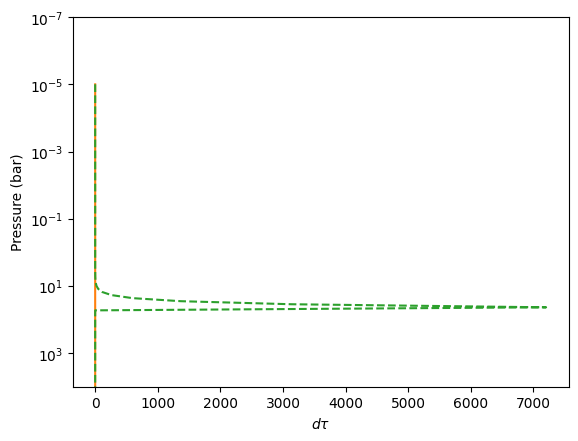

In [24]:
plt.plot(dtau_nh3, Parr, color="C1")
plt.plot(dtau_h2o, Parr, color="C2", ls="dashed")
plt.yscale("log")
plt.ylim(1.e-7, 10000)
plt.xlabel("$d\\tau$")
plt.ylabel("Pressure (bar)")
#plt.xscale("log")
plt.gca().invert_yaxis()

Let's compare with CIA

In [25]:
#CIA
from exojax.utils.grids import wavenumber_grid

nus, wav, res = wavenumber_grid(9500, 30000, 1000, xsmode="premodit", unit="AA")

from exojax.database import contdb 

cdbH2H2 = contdb.CdbCIA('.database/H2-H2_2011.cia', nus)

xsmode =  premodit
xsmode assumes ESLOG in wavenumber space: xsmode=premodit
Your wavelength grid is in ***  descending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.
Load CIA:  H2-H2


/home/kawahara/exojax/src/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/grids.py:249: UserWarning: Resolution may be too small. R=868.7669794117727
  warnings.warn("Resolution may be too small. R=" + str(resolution), UserWarning)


In [26]:
from exojax.rt.layeropacity import layer_optical_depth_CIA

mmw = 2.33  #mean molecular weight
mmrH2 = 0.74
molmassH2 = molmass_isotope("H2")
vmrH2 = (mmrH2 * mmw / molmassH2)  #VMR
dtaucH2H2=layer_optical_depth_CIA(nus,Tarr,Parr,dParr,vmrH2,vmrH2,\
            mmw,g,cdbH2H2.nucia,cdbH2H2.tcia,cdbH2H2.logac)

In [27]:
dtau_cloud = dtau_nh3 + dtau_h2o
dtau = dtaucH2H2 + dtau_cloud[:, None]


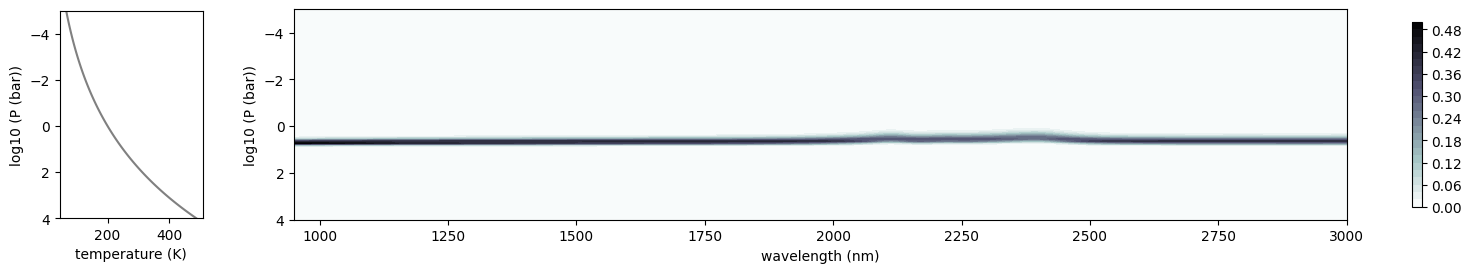

In [28]:
from exojax.plot.atmplot import plotcf

plotcf(nus, dtau, Tarr, Parr, dParr, unit="nm")
plt.show()

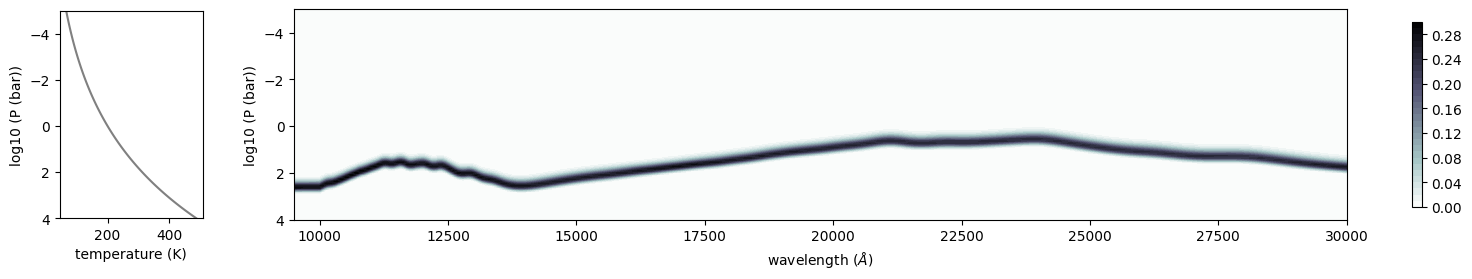

In [29]:
from exojax.plot.atmplot import plotcf

plotcf(nus, dtaucH2H2, Tarr, Parr, dParr, unit="AA")
plt.show()

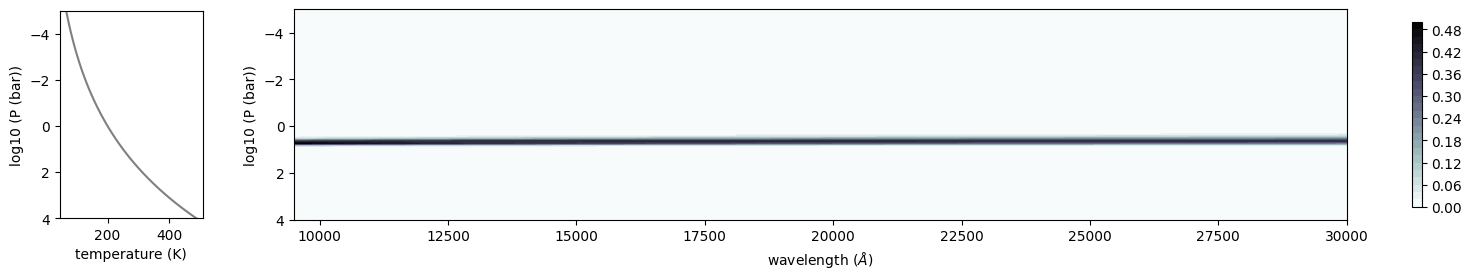

In [30]:
from exojax.plot.atmplot import plotcf

plotcf(nus,
       dtau_cloud[:, None] + np.zeros_like(dtaucH2H2),
       Tarr,
       Parr,
       dParr,
       unit="AA")
plt.show()

In [31]:
from exojax.rt import planck
from exojax.rt.rtransfer import rtrun_emis_pureabs_fbased2st

sourcef = planck.piBarr(Tarr, nus)
F0 = rtrun_emis_pureabs_fbased2st(dtau, sourcef)
F0CIA = rtrun_emis_pureabs_fbased2st(dtaucH2H2, sourcef)
F0cl = rtrun_emis_pureabs_fbased2st(dtau_cloud[:, None] + np.zeros_like(dtaucH2H2), sourcef)


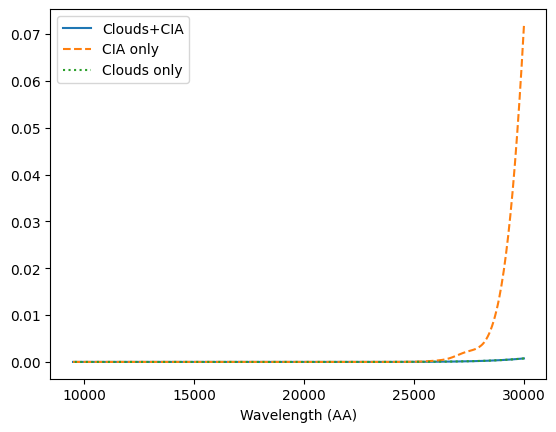

In [32]:
plt.plot(wav, F0, label="Clouds+CIA")
plt.plot(wav, F0CIA, label="CIA only", ls="dashed")
plt.plot(wav, F0cl, label="Clouds only", ls="dotted")
plt.xlabel("Wavelength (AA)")
plt.legend()
plt.show()